# First Practice

## 1. One dimensional case

### 1.1 Plot this function within the range $x \in [−2, 2]$.

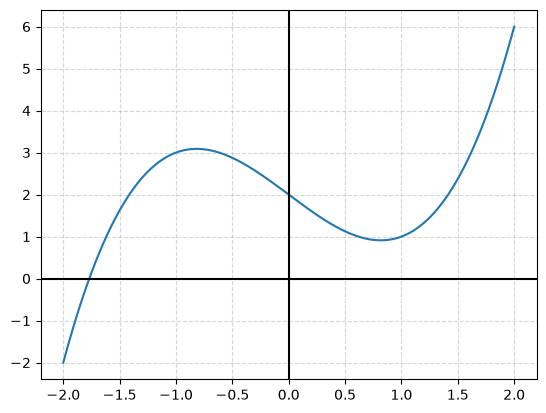

In [35]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-2, 2, 1000)
f_x = x**3 - 2*x + 2

plt.plot(x, f_x)
plt.axhline(0, color='black')
plt.axvline(0, color='black')
plt.grid(True, linestyle='--', alpha=0.5)


### 1.2 Compute analytically the points $x^{*}$ that satisfy $f'(x)=0$

Now we find all points $x$ where $f'(x)=0$.

We have $f'(x)=3x^{2} - 2 = 0$, by solving we find that $x_{1} = \sqrt{\frac{2}{3}}$ and $x_{2} = -\sqrt{\frac{2}{3}}$ satisfy the condition.

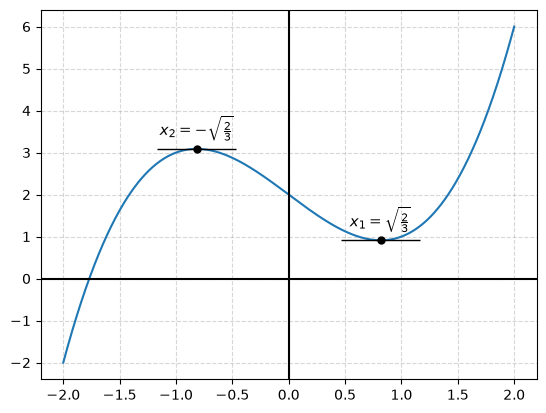

In [38]:
x = np.linspace(-2, 2, 1000)
f_x = x**3 - 2*x + 2

x_1 = np.sqrt(2/3)
x_2 = -np.sqrt(2/3)

critical_points_x = [x_1, x_2]
critical_points_y = [px**3 - 2*px + 2 for px in critical_points_x]
labels = [r'$x_1 = \sqrt{\frac{2}{3}}$', r'$x_2 = -\sqrt{\frac{2}{3}}$']

plt.plot(x, f_x)
plt.axhline(0, color='black')
plt.axvline(0, color='black')
plt.grid(True, linestyle='--', alpha=0.5)

bar_width = 0.7
line_width = 1

for cx, cy, label in zip(critical_points_x, critical_points_y, labels):
    
    plt.hlines(y=cy, xmin=cx - bar_width/2, xmax=cx + bar_width/2, color='black', linewidth=line_width)
    
    plt.plot(cx, cy, 'ko', markersize=5)
    
    offset = 0.35
    plt.annotate(
        label, 
        (cx, cy), 
        textcoords="offset points", 
        xytext=(0, 10 ), 
        ha='center',
        fontsize=11
    )

plt.show()


### 1.3. Second-order Taylor Expansion and Minimum/Maximum Conditions

To determine whether the critical points $x^*$ found in the previous section ($x_1 = \sqrt{\frac{2}{3}}$ and $x_2 = -\sqrt{\frac{2}{3}}$) are local minima or local maxima, we use the **2nd order Taylor expansion** of $f(x)$ around $x^*$:

$$f(x^* + d) \approx f(x^*) + d \cdot f'(x^*) + \frac{1}{2} d^2 f''(x^*)$$

where $d \in \mathbb{R}$ represents a small perturbation around $x^*$. 

Since $x^*$ is a critical point, $f'(x^*) = 0$, we get:

$$f(x^* + d) \approx f(x^*) + \frac{1}{2} d^2 f''(x^*)$$

#### Analysis of the Second Derivative:
1. If $f''(x^*) > 0$, for any $d \neq 0$, $\frac{1}{2} d^2 f''(x^*) > 0$. Therefore $f(x^* + d) > f(x^*)$ and the funcion is a local minimum
2. If $f''(x^*) < 0$, for any $d \neq 0$, $\frac{1}{2} d^2 f''(x^*) < 0$. Therefore $f(x^* + d) < f(x^*)$ and the funcion is a local maximum
---

#### Analytical Calculation of $f''(x)$:
Given $f(x) = x^3 - 2x + 2$, its first derivative is $f'(x) = 3x^2 - 2$.  
And taking the derivative again gives $f''(x) = 6x$

Evaluating at our critical points:
* **At $x_1 = \sqrt{\frac{2}{3}} \approx 0.8165$:**
  $$f''\left(\sqrt{\frac{2}{3}}\right) = 6\sqrt{\frac{2}{3}} \approx 4.899 > 0$$
  Since $f''\left(x_1\right) > 0$, **$x_1 = \sqrt{\frac{2}{3}}$ is a local minimum**.

* **At $x_2 = -\sqrt{\frac{2}{3}} \approx -0.8165$:**
  $$f''\left(-\sqrt{\frac{2}{3}}\right) = -6\sqrt{\frac{2}{3}} \approx -4.899 < 0$$
  Since $f''\left(x_2\right) < 0$, **$x_2 = -\sqrt{\frac{2}{3}}$ is a local maximum**.

At x1 =  sqrt(2/3) ≈ 0.8165:  f''(x1) =  4.8990 > 0   LOCAL MINIMUM
At x2 = -sqrt(2/3) ≈ -0.8165: f''(x2) = -4.8990 < 0   LOCAL MAXIMUM



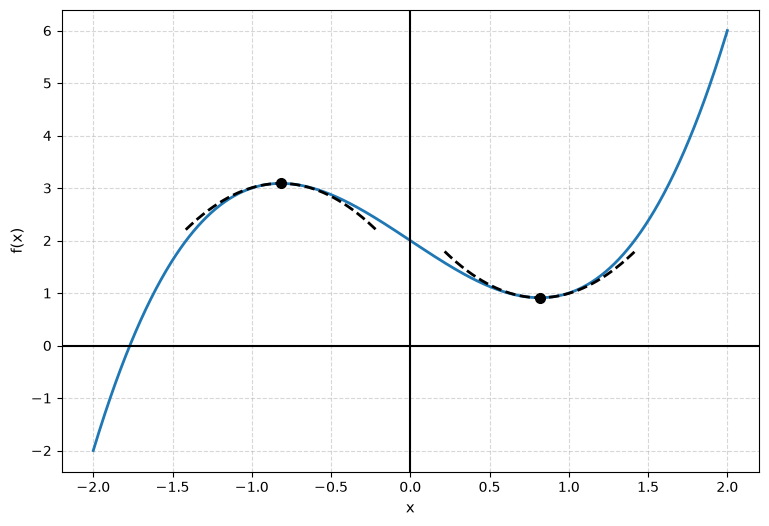

In [ ]:
def f(x):
    return x**3 - 2*x + 2

def df(x):
    return 3*x**2 - 2

def d2f(x):
    return 6*x

x1 = np.sqrt(2/3)
x2 = -np.sqrt(2/3)

print(f"At x1 =  sqrt(2/3) ≈ {x1:.4f}:  f''(x1) =  {d2f(x1):.4f} > 0   LOCAL MINIMUM")
print(f"At x2 = -sqrt(2/3) ≈ {x2:.4f}: f''(x2) = {d2f(x2):.4f} < 0   LOCAL MAXIMUM\n")

# Defining space for Taylor approximations plot
x = np.linspace(-2, 2, 1000)
d = np.linspace(-0.6, 0.6, 200)

# Taylor approximations
taylor_x1 = f(x1) + 0.5 * (d**2) * d2f(x1) 
taylor_x2 = f(x2) + 0.5 * (d**2) * d2f(x2) 

plt.figure(figsize=(9, 6))
plt.plot(x, f(x), label=r'$f(x) = x^3 - 2x + 2$', color='tab:blue', linewidth=2)

# The discontinuous lines
plt.plot(x1 + d, taylor_x1, '--', color='black', linewidth=2, 
         label=r'Taylor approximation in $x_1$')

plt.plot(x2 + d, taylor_x2, '--', color='black', linewidth=2, 
         label=r'Taylor approximation in $x_2$')

plt.plot(x1, f(x1), 'ko', markersize=7)
plt.plot(x2, f(x2), 'ko', markersize=7)

plt.xlabel('x', fontsize=11)
plt.ylabel('f(x)', fontsize=11)
plt.axhline(0, color='black')
plt.axvline(0, color='black')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### 1.4. Plot of $f(x)$ and its Second Derivative $f''(x)$

In this section, we plot $f(x) = x^3 - 2x + 2$ alongside its second derivative $f''(x) = 6x$ in the range $x \in [-2, 2]$.

f(x) in blue, f''(x) in grey


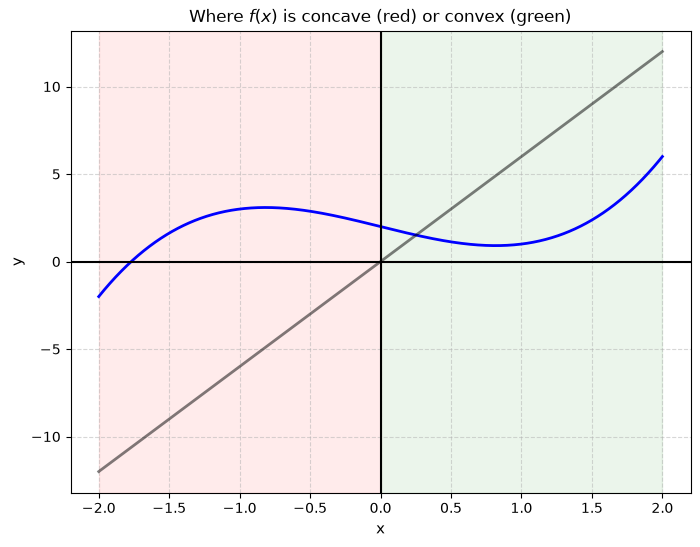

In [46]:
x = np.linspace(-2, 2, 1000)

f_x = x**3 - 2*x + 2
d2f_x = 6*x

plt.figure(figsize=(8, 6))

plt.plot(x, f_x, color='blue', linewidth=2, label=r'$f(x) = x^3 - 2x + 2$')

plt.plot(x, d2f_x, color='black', alpha=0.5, linewidth=2, label=r"$f''(x) = 6x$ (50% opacidad)")

plt.axhline(0, color='black', linestyle='-')
plt.axvline(0, color='black', linestyle='-')

# Fill each half with colours
plt.axvspan(-2, 0, color='red', alpha=0.08)
plt.axvspan(0, 2, color='green', alpha=0.08)

# Detalles estéticos
plt.title(r'Where $f(x)$ is concave (red) or convex (green)', fontsize=12)
plt.xlabel('x', fontsize=11)
plt.ylabel('y', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

print("f(x) in blue, f''(x) in grey")

plt.show()

## 2. Two dimensional case

### 2.1 A simple two-dimensional function

#### 2.1.1 Plot this function

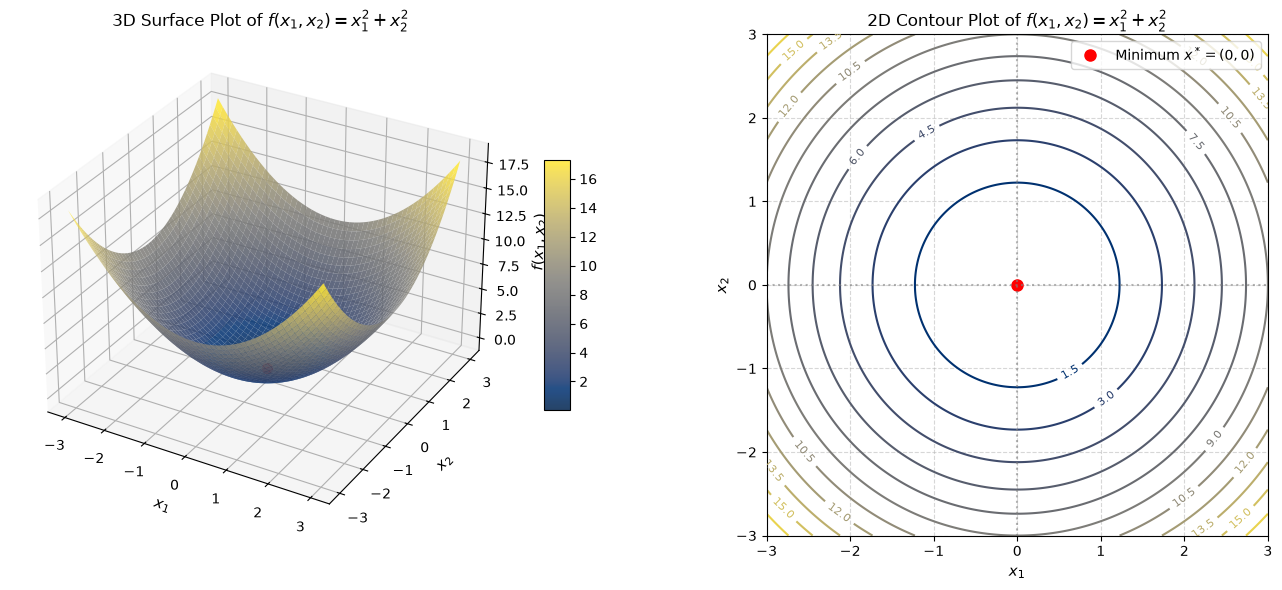

In [52]:
x1 = np.linspace(-3, 3, 1000)
x2 = np.linspace(-3, 3, 1000)
X1, X2 = np.meshgrid(x1, x2)

Z = X1**2 + X2**2

fig = plt.figure(figsize=(14, 6))

# First graphic
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(X1, X2, Z, cmap='cividis', edgecolor='none', alpha=0.85)
ax1.scatter([0], [0], [0], color='red', s=50, label='Minimum $(0,0)$', zorder=5)

ax1.set_title(r'3D Surface Plot of $f(x_1, x_2) = x_1^2 + x_2^2$', fontsize=12)
ax1.set_xlabel('$x_1$', fontsize=11)
ax1.set_ylabel('$x_2$', fontsize=11)
ax1.set_zlabel('$f(x_1, x_2)$', fontsize=11)
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)

# Second graphic
ax2 = fig.add_subplot(1, 2, 2)
contour = ax2.contour(X1, X2, Z, levels=15, cmap='cividis')
ax2.clabel(contour, inline=True, fontsize=8)
ax2.plot(0, 0, 'ro', markersize=8, label='Minimum $x^*=(0,0)$')

ax2.axhline(0, color='gray', linestyle=':', alpha=0.6)
ax2.axvline(0, color='gray', linestyle=':', alpha=0.6)

ax2.set_title(r'2D Contour Plot of $f(x_1, x_2) = x_1^2 + x_2^2$', fontsize=12)
ax2.set_xlabel('$x_1$', fontsize=11)
ax2.set_ylabel('$x_2$', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.set_aspect('equal')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

### 2.1.2. Analytical Computation of the Gradient $\nabla f(x)$

Given the function $$f(x) = x_1^2 + x_2^2$$

The gradient vector $\nabla f(x)$ is defined as the vector of first-order partial derivatives with respect to each component $x_1$ and $x_2$.

1. With respect to $x_1$:
   $$\frac{\partial f}{\partial x_1} = \frac{\partial}{\partial x_1}(x_1^2 + x_2^2) = 2x_1$$

2. With respect to $x_2$:
   $$\frac{\partial f}{\partial x_2} = \frac{\partial}{\partial x_2}(x_1^2 + x_2^2) = 2x_2$$

Therefore, the gradient is:

$$\nabla f(x) = \begin{pmatrix} 2x_1 \\ 2x_2 \end{pmatrix}$$

---

#### Finding the Critical Point $x^*$:
To find the critical point $x^*$ where $\nabla f(x^*) = 0$:

$$\nabla f(x^*) = \begin{pmatrix} 2x_1^* \\ 2x_2^* \end{pmatrix} = \begin{pmatrix} 0 \\ 0 \end{pmatrix}$$

Solving the system:
* $2x_1^* = 0 \implies x_1^* = 0$
* $2x_2^* = 0 \implies x_2^* = 0$

The unique critical point where $\nabla f(x^*) = 0$ is:

$$x^* = \begin{pmatrix} 0 \\ 0 \end{pmatrix}$$

### 2.1.3 Taylor exansion, Hessian matrix and eigenvalues

$\nabla ^{2} f(x)$ is defined as the matrix of all the second-order partial derivatives with respect to $x_1$ and $x_2$.

We calculate all the possible combinations:
\begin{align}
\frac{\partial f^2}{\partial^{2}x_1} &= 2 \\
\frac{\partial f^2}{\partial^{2}x_2} &= 2 \\
\frac{\partial f^2}{\partial x_{1} \partial x_{2}} &= 0 \\
\frac{\partial f^2}{\partial x_{2} \partial x_{1}} &= 0 \\
\end{align}

Therefore, the Hessian matrix is:
$$\nabla ^{2} f(x) = \begin{pmatrix} 2 & 0 \\ 0 & 2 \end{pmatrix}$$

We observe that $\nabla^{2}f(x)$ is constant, therefore, for all $x$ we have the same Hessian matrix.

### 2.2 A two dimensional function with multiple minima

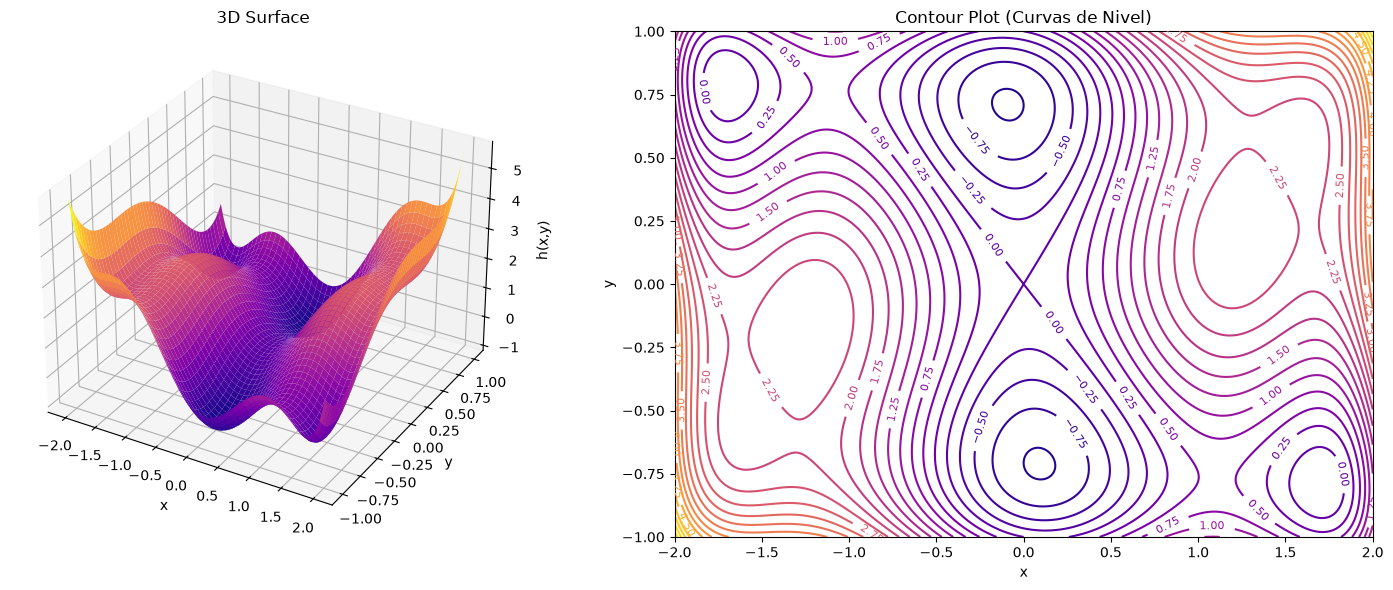

In [ ]:
x = np.linspace(-2, 2, 1000)
y = np.linspace(-1, 1, 1000)
X, Y = np.meshgrid(x,y)

h = X**2 * (4-2.1*X**2 + 1/3 * X**4) + X*Y + Y**2 * (-4+4*Y**2)


fig = plt.figure(figsize=(15, 6))

# Gráfico 3D
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, h, cmap='cividis')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('h(x,y)')
ax1.set_title('3D Surface')

# Curvas de nivel (2D)
ax2 = fig.add_subplot(122)
contour = ax2.contour(X, Y, h, levels=30, cmap='cividis')
ax2.clabel(contour, inline=True, fontsize=8)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Contour Plot (Curvas de Nivel)')

plt.tight_layout()
plt.show()


In [ ]:
## Calculamos el gradiente de la función h(x,y)

def grad_f(x,y):
    df_dx = 8*x - 8.4*x**3 + (4/3)*x**5 + y
    df_dy = x + 8*y - 16*y**3
    return np.array([df_dx, df_dy])

def norm_grad_f(x,y):
    grad = grad_f(x,y)
    return grad[0]**2 + grad[1]**2

In [ ]:
grad_f(0,0)

array([0., 0.])